In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import pandas as pd

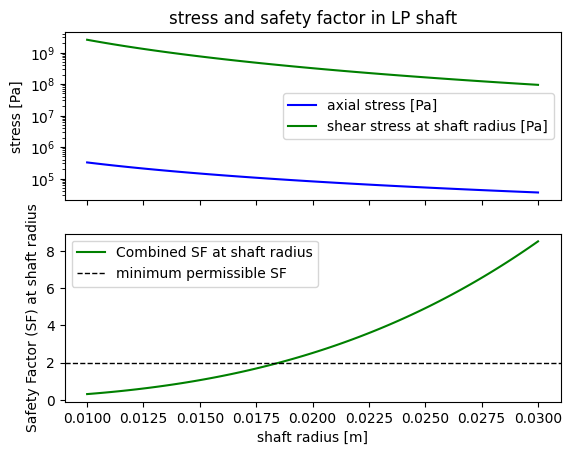

(3847162.2576624015,
 3988.891792726691,
 101.72591120000004,
 array([7842.43020421, 7688.65706295, 7540.79827328, 7398.51906057,
        7261.50944834, 7129.48200382, 7002.16982518, 6879.32474053,
        6760.71569328, 6646.1272917 , 6535.35850351, 6428.22147886,
        6324.54048726, 6224.15095572, 6126.89859704, 6032.63861862,
        5941.23500319, 5852.55985389, 5766.49279721, 5682.92043783,
        5601.73586015, 5522.83817198, 5446.13208625, 5371.52753713,
        5298.93932717, 5228.2868028 , 5159.4935554 , 5092.48714559,
        5027.19884885, 4963.56342038, 4901.51887763, 4841.00629889,
        4781.96963671, 4724.3555447 , 4668.11321679, 4613.19423777,
        4559.55244431, 4507.14379552, 4455.92625239, 4405.85966528,
        4356.905669  , 4309.02758473, 4262.19032837, 4216.36032484,
        4171.50542777, 4127.59484432, 4084.59906469, 4042.48979598,
        4001.23990011, 3960.82333546, 3921.2151021 , 3882.3911902 ,
        3844.32853147, 3807.0049535 , 3770.39913664, 3

In [17]:
#LP SHAFT RADIUS
#axial force = mdot * delta(axial velocity)
#tangential force = 

mdot_air_45 = 24.340     #[kg s^-1]
mdot_air_5 = 25.067     #[kg s^-1]
cp = 1212               #[J K^-1]

T_0_45 = 1829.12        # TET [K]
T_0_5 = 1630.52        # Turbine exit Temperature [K]
omega_LPT = 9210 * np.pi/30  #angular velocity [rad s^-1]
efficiency_to_shaft = 0.87      #empirical value from propulsion notes

W_sh = efficiency_to_shaft*cp*(mdot_air_45*T_0_45 - mdot_air_5*T_0_5)         #shaft power [W]

Torque = W_sh/omega_LPT         #[N m]

V_x = 139.9256
theta_41 = 49.23 * np.pi/180        # [rad]
theta_44 = -2.72 * np.pi/180        # [rad]

F_n = -V_x*(mdot_air_45-mdot_air_5)    #Positive in rightward direction

#STRESSES
R_ii = np.linspace(0.01, 0.03, 101)


tau = 2*Torque/(np.pi*R_ii**3)       #shear stress [Pa]
sigma_x = F_n/(np.pi*R_ii**2)        #axial stress [Pa]
sigma_y = 1600e6                  #yield stress [Pa]

SF_shaft = sigma_y/np.sqrt(sigma_x**2 + 4*tau**2)
permissible_SF = 2

#plotting

fig, (ax_stress, ax_SF_shaft) = plt.subplots(2, 1, sharex=True)

ax_stress.set_title('stress and safety factor in LP shaft')
ax_SF_shaft.plot(R_ii, SF_shaft, color='green', label='Combined SF at shaft radius')
ax_SF_shaft.set_xlabel('shaft radius [m]')
ax_SF_shaft.set_ylabel('Safety Factor (SF) at shaft radius')
ax_SF_shaft.axhline(y=permissible_SF, color='black', linestyle='dashed', linewidth=1, label='minimum permissible SF')
ax_SF_shaft.legend()

ax_stress.plot(R_ii, sigma_x, color='blue', label='axial stress [Pa]')
ax_stress.plot(R_ii, tau, color='green', label='shear stress at shaft radius [Pa]')
ax_stress.set_ylabel('stress [Pa]')
ax_stress.set_yscale('log')
ax_stress.legend()

plt.savefig('LPT_shaft_stress_and_SF.png')
plt.show()

R_ii = R_ii[SF_shaft >= permissible_SF][0]        #returns shaft radius for which safety factor is 2

W_sh, Torque, F_n, tau/sigma_x, R_ii

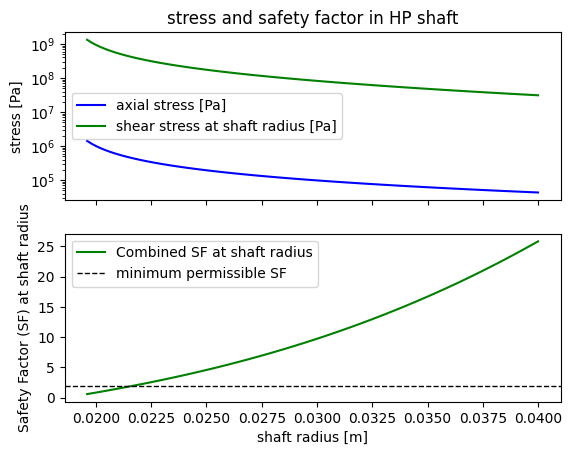

(5436767.4386688005,
 2969.706774183726,
 169.4499015999998,
 array([940.94463539, 940.38476877, 939.73214525, 938.98997626,
        938.16139438, 937.24945414, 936.25713295, 935.18733199,
        934.04287728, 932.82652072, 931.54094118, 930.18874568,
        928.77247059, 927.29458281, 925.75748102, 924.16349696,
        922.5148967 , 920.81388195, 919.06259132, 917.26310168,
        915.41742945, 913.52753189, 911.59530849, 909.62260216,
        907.61120065, 905.56283777, 903.47919469, 901.36190122,
        899.21253707, 897.03263308, 894.82367247, 892.58709204,
        890.32428337, 888.03659398, 885.72532853, 883.39174991,
        881.0370804 , 878.66250275, 876.26916126, 873.85816283,
        871.43057802, 868.98744203, 866.52975574, 864.05848664,
        861.57456981, 859.07890881, 856.57237664, 854.0558166 ,
        851.53004316, 848.99584279, 846.45397481, 843.90517218,
        841.35014228, 838.7895677 , 836.22410694, 833.65439519,
        831.08104498, 828.50464691, 825.925

In [18]:
#HP SHAFT RADIUS
#axial force = mdot * delta(axial velocity)
#tangential force = 

mdot_air_41 = 23.129     #[kg s^-1]
mdot_air_44 = 24.340     #[kg s^-1]
cp = 1248               #[J K^-1]

T_0_41 = 2129.62        # TET [K]
T_0_44 = 1829.12        # Turbine exit Temperature [K]
omega_HPT = 17482.3 * np.pi/30  #angular velocity [rad s^-1]
efficiency_to_shaft = 0.92      #empirical value from propulsion notes

W_sh = efficiency_to_shaft*cp*(mdot_air_41*T_0_41 - mdot_air_44*T_0_44)         #shaft power [W]

Torque = W_sh/omega_HPT         #[N m]

V_x = 139.9256
theta_41 = 42.84 * np.pi/180        # [rad]
theta_44 = 10.42 * np.pi/180        # [rad]

F_n = -V_x*(mdot_air_41-mdot_air_44)    #Positive in rightward direction

#STRESSES
R_i = np.linspace(R_ii+0.001, 0.04, 101)

Area = np.pi*(R_i**2 - R_ii**2)
J = 0.5*np.pi*(R_i**4 - R_ii**4)

tau = Torque*R_i/J       #shear stress [Pa]
sigma_x = F_n/Area        #axial stress [Pa]
sigma_y = 1600e6                  #yield stress [Pa]

SF_shaft = sigma_y/np.sqrt(sigma_x**2 + 4*tau**2)
permissible_SF = 2

#plotting

fig, (ax_stress, ax_SF_shaft) = plt.subplots(2, 1, sharex=True)


ax_SF_shaft.plot(R_i, SF_shaft, color='green', label='Combined SF at shaft radius')
ax_SF_shaft.set_xlabel('shaft radius [m]')
ax_SF_shaft.set_ylabel('Safety Factor (SF) at shaft radius')
ax_SF_shaft.axhline(y=permissible_SF, color='black', linestyle='dashed', linewidth=1, label='minimum permissible SF')
ax_SF_shaft.legend()

ax_stress.set_title('stress and safety factor in HP shaft')
ax_stress.plot(R_i, sigma_x, color='blue', label='axial stress [Pa]')
ax_stress.plot(R_i, tau, color='green', label='shear stress at shaft radius [Pa]')
ax_stress.set_ylabel('stress [Pa]')
ax_stress.set_yscale('log')
ax_stress.legend()

plt.savefig('HPT_shaft_stress_and_SF.png')
plt.show()

R_i = R_i[SF_shaft >= permissible_SF][0]        #returns shaft radius for which safety factor is 2

W_sh, Torque, F_n, tau/sigma_x, R_i

In [19]:
#HARDCODED VARIABLES

t = 0.5        #disc thickness [m]
T_g = 2193.28    #Gas temperature [K]
T_c = 752.86     #cooling air temperature [K]
eps = 0.788    #cooling constant [1]
rho_disc = 8220.9317    #disc density [kg m^-3]
rho_blade = 8220.9317   #blade density [kg m^-3]
R_m = 0.170          #mean radius of blade [m]
sigma_y = 493.554e6


h_blade = 0.0378      #blade height [m]
t_blade = 0.0042      #blade thickness [m]
c_blade = 0.02819      #blade chord length [m]
N_b = 38          #number of blades [1]
nu = 0.313          #inconel 718 poisson ratio [1]

R_o = R_m - 0.5*h_blade          #outer radius of disc [m]

R_i, R_o, omega_HPT

(np.float64(0.021844), 0.1511, 1830.742174928428)

In [20]:
#INTERMEDIATE VARIABLES

F_rim = rho_blade * h_blade*t_blade*c_blade * R_m * omega_HPT**2
T_m = T_g - eps*(T_g-T_c)

In [21]:
F_rim, T_m

(20963.341085488053, 1058.2290400000002)

In [22]:
r = np.linspace(R_i, R_o, 101)    #radius for plotting stresses [m]
r

array([0.021844  , 0.02313656, 0.02442912, 0.02572168, 0.02701424,
       0.0283068 , 0.02959936, 0.03089192, 0.03218448, 0.03347704,
       0.0347696 , 0.03606216, 0.03735472, 0.03864728, 0.03993984,
       0.0412324 , 0.04252496, 0.04381752, 0.04511008, 0.04640264,
       0.0476952 , 0.04898776, 0.05028032, 0.05157288, 0.05286544,
       0.054158  , 0.05545056, 0.05674312, 0.05803568, 0.05932824,
       0.0606208 , 0.06191336, 0.06320592, 0.06449848, 0.06579104,
       0.0670836 , 0.06837616, 0.06966872, 0.07096128, 0.07225384,
       0.0735464 , 0.07483896, 0.07613152, 0.07742408, 0.07871664,
       0.0800092 , 0.08130176, 0.08259432, 0.08388688, 0.08517944,
       0.086472  , 0.08776456, 0.08905712, 0.09034968, 0.09164224,
       0.0929348 , 0.09422736, 0.09551992, 0.09681248, 0.09810504,
       0.0993976 , 0.10069016, 0.10198272, 0.10327528, 0.10456784,
       0.1058604 , 0.10715296, 0.10844552, 0.10973808, 0.11103064,
       0.1123232 , 0.11361576, 0.11490832, 0.11620088, 0.11749

In [23]:
A = (3 + nu)*rho_disc*omega_HPT**2/8
A

11410557452.82063

In [24]:
B = (N_b*F_rim*R_o)/(2*np.pi*t*(R_o**2-R_i**2))
B

np.float64(1713967.0846855047)

In [25]:
C = (1+3*nu)/(3+nu)
C

0.5852701479022034

In [26]:
sigma_r = A*(R_i**2 + R_o**2 - (R_i**2 * R_o**2/r**2) - r**2) + B*(1 - (R_i/r)**2)
sigma_theta = A*(R_i**2 + R_o**2 + (R_i**2 * R_o**2/r**2) - C*r**2) + B*(1 + (R_i/r)**2)
sigma_p = np.max([sigma_r, sigma_theta], axis=0)
SF = sigma_y * 1/sigma_p
SF

array([0.93703355, 0.99137096, 1.04266512, 1.09101089, 1.1365357 ,
       1.17938798, 1.21972809, 1.25772166, 1.29353458, 1.32732957,
       1.35926373, 1.38948697, 1.41814112, 1.44535947, 1.47126661,
       1.49597858, 1.51960315, 1.54224017, 1.56398206, 1.58491426,
       1.60511573, 1.62465948, 1.64361296, 1.66203862, 1.67999425,
       1.69753346, 1.71470599, 1.73155811, 1.74813294, 1.76447071,
       1.78060906, 1.79658331, 1.81242664, 1.82817036, 1.84384405,
       1.8594758 , 1.87509229, 1.89071903, 1.90638044, 1.92210001,
       1.93790039, 1.95380352, 1.96983074, 1.98600289, 2.00234036,
       2.01886322, 2.0355913 , 2.05254423, 2.06974156, 2.0872028 ,
       2.10494752, 2.12299539, 2.14136625, 2.16008021, 2.17915768,
       2.19861945, 2.21848677, 2.2387814 , 2.25952569, 2.28074266,
       2.30245606, 2.32469046, 2.34747134, 2.37082516, 2.39477945,
       2.41936293, 2.44460558, 2.47053879, 2.49719544, 2.52461005,
       2.55281889, 2.58186016, 2.61177413, 2.6426033 , 2.67439

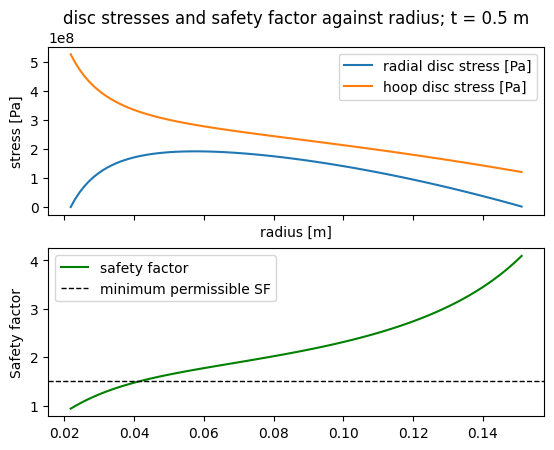

In [27]:
fig, (ax_sigma, ax_SF) = plt.subplots(2, 1, sharex=True)

ax_sigma.set_title('disc stresses and safety factor against radius; t = 0.5 m')
ax_sigma.set_xlabel('radius [m]')
ax_sigma.set_ylabel('stress [Pa]')
ax_sigma.plot(r, sigma_r, label='radial disc stress [Pa]')
ax_sigma.plot(r, sigma_theta, label='hoop disc stress [Pa]')


ax_SF.set_ylabel('Safety factor')
ax_SF.plot(r, SF, label='safety factor', color='green')
ax_SF.axhline(y=1.5, color='black', linestyle='dashed', linewidth=1, label='minimum permissible SF')
ax_SF.legend()

ax_sigma.legend()

plt.savefig('disc_stress_and_SF.png')

In [28]:
#CONSTANT STRESS
SF_constant = 1.5
sigma_p = sigma_y/SF_constant
sigma_p

329036000.0

In [29]:
B = rho_disc*omega_HPT**2/(2*sigma_p)
#h_0 = F_rim/(2*sigma_p*np.pi*R_o)
h_0 = 0.0252        #axial chord [m]
B, h_0

(41.86990741195944, 0.0252)

In [30]:
R_i = 0.023
r_plot = np.linspace(R_i, R_o, 101)
h = h_0*np.exp(B*(R_o**2-r_plot**2))
h

array([0.06411225, 0.06394987, 0.06377914, 0.06360012, 0.0634129 ,
       0.06321753, 0.06301411, 0.06280271, 0.06258342, 0.06235633,
       0.06212152, 0.0618791 , 0.06162915, 0.06137178, 0.06110708,
       0.06083517, 0.06055614, 0.06027011, 0.05997719, 0.05967749,
       0.05937114, 0.05905823, 0.05873891, 0.05841328, 0.05808148,
       0.05774363, 0.05739985, 0.05705028, 0.05669505, 0.05633429,
       0.05596813, 0.05559672, 0.05522017, 0.05483865, 0.05445227,
       0.05406119, 0.05366555, 0.05326547, 0.05286112, 0.05245263,
       0.05204014, 0.05162381, 0.05120376, 0.05078016, 0.05035314,
       0.04992285, 0.04948944, 0.04905305, 0.04861382, 0.04817191,
       0.04772746, 0.04728061, 0.04683151, 0.0463803 , 0.04592713,
       0.04547213, 0.04501546, 0.04455725, 0.04409765, 0.04363678,
       0.0431748 , 0.04271185, 0.04224805, 0.04178354, 0.04131847,
       0.04085296, 0.04038714, 0.03992114, 0.03945511, 0.03898915,
       0.0385234 , 0.03805799, 0.03759303, 0.03712865, 0.03666

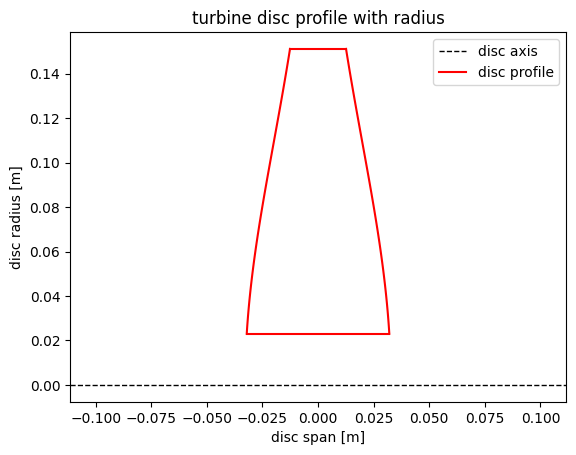

In [31]:
#PLOT DISC PROFILE

h_positive = h/2
h_negative = -h_positive

h_o = h[-1]
h_i = h[0]




fig, ax = plt.subplots()
ax.plot([-h_i/2, h_i/2], [R_i, R_i], color='red')
ax.plot([-h_o/2, h_o/2], [R_o, R_o], color='red')

ax.axhline(y=0, color='black', linestyle='dashed', linewidth=1, label='disc axis')

ax.plot(h_positive, r_plot, color='red', label='disc profile')
ax.plot(h_negative, r_plot, color='red')
ax.axis('equal')

#Title and axis labels and other silly things
ax.set_title('turbine disc profile with radius')
ax.set_xlabel('disc span [m]')
ax.set_ylabel('disc radius [m]')
ax.legend()

plt.savefig('disc_profile.png')